# kplot

kplot is a Python plotting toolkit for exploratory data analysis. It provides reusable helpers for styling figures, scatter and embedding plots, categorical summaries, heatmaps, hierarchical clustering, and related ranking workflows.

## Installation

```bash
pip install python-kplot
```

## Quick start

The examples below follow the notebooks under `nbs/` in order. Each function example lives in its own cell and starts with a short comment derived from the function docstring.

### 01 utils

In [ ]:
from kplot.utils import set_sns, save_svg, save_pdf, save_show, get_color_dict, get_plt_color, get_hue_big, add_stats

In [ ]:
import seaborn as sns
from matplotlib import pyplot as plt

# Set up the objects used by the examples below.
df = sns.load_dataset('tips')
df.shape

(244, 7)

In [ ]:
# Set seaborn defaults for notebook display and saved figures.
set_sns(dpi=50)

[<matplotlib.lines.Line2D>]

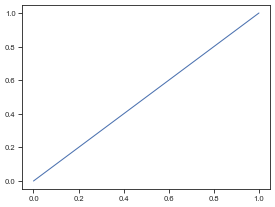

In [ ]:
# Save the current matplotlib figure as SVG with editable text.
plt.figure()
plt.plot([0, 1], [0, 1])
# save_svg(Path('nbs') / '_tmp_utils.svg')

[<matplotlib.lines.Line2D>]

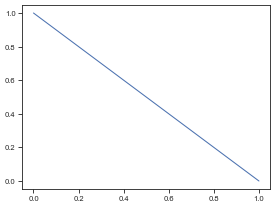

In [ ]:
# Save the current matplotlib figure as PDF with TrueType fonts.
plt.figure()
plt.plot([0, 1], [1, 0])
# save_pdf(Path('nbs') / '_tmp_utils.pdf')

[<matplotlib.lines.Line2D>]

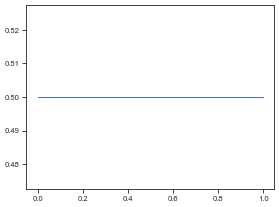

In [ ]:
# Show the current figure or save it, then close open figures.
plt.figure()
plt.plot([0, 1], [0.5, 0.5])
# save_show(path=Path('nbs') / '_tmp_utils_show.png')

In [ ]:
# Assign colors to labels while tolerating duplicate category names.
get_color_dict(['A', 'B', 'C'], palette='Set2')

{'A': (0.4, 0.7607843137254902, 0.6470588235294118),
 'B': (0.9882352941176471, 0.5529411764705883, 0.3843137254901961),
 'C': (0.5529411764705883, 0.6274509803921569, 0.796078431372549)}

In [ ]:
# Return colors in plotting order for a dict, list, or named palette.
get_plt_color('Set2', ['a', 'b'])

[(0.4, 0.7607843137254902, 0.6470588235294118),
 (0.9882352941176471, 0.5529411764705883, 0.3843137254901961)]

In [ ]:
# Filter a hue column down to categories that meet a count threshold.
# get_hue_big(df, 'day', cnt_thr=40).tolist()

<Axes: xlabel='sex', ylabel='total_bill'>

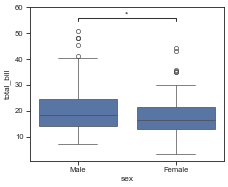

In [ ]:
# If `value` is str: compare between groups (x=group, y=value) If `value` is list/tuple: compare among values within each group (x=group, hue='variable')
fig, ax = plt.subplots(figsize=(5, 4))
sns.boxplot(data=df, x='sex', y='total_bill', ax=ax)
add_stats(ax, df, value='total_bill', group='sex')

### 02 scatter

In [ ]:
from kplot.scatter import reduce_feature, plot_2d, plot_cluster, plot_rel

In [ ]:
import seaborn as sns

# Set up the objects used by the examples below.
df = sns.load_dataset('penguins').dropna().reset_index(drop=True)
df2 = df[['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']]
print(df.shape)
print(df2.shape)

(333, 7)
(333, 4)


In [ ]:
# Reduce a feature matrix to a lower-dimensional embedding dataframe.
reduce_feature(df2, method='pca', n=2)

,PCA1,PCA2
0,-457.325073,-13.351587
1,-407.252205,-9.179113
2,-957.044676,8.160444
3,-757.115802,1.867653
4,-557.177302,-3.389158
...,...,...
328,718.068699,2.338199
329,643.090909,4.280699
330,1543.098355,-2.232010
331,992.994900,-4.605154


<Axes: xlabel='PCA1', ylabel='PCA2'>

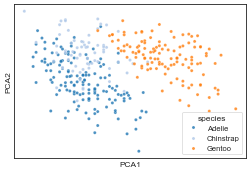

In [ ]:
# Plot the first two columns of an embedding dataframe.
df2 = reduce_feature(df[['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']], method='pca', n=2)
df2['species'] = df['species'].values
plot_2d(df2, hue='species', legend=True)

<Axes: xlabel='PCA1', ylabel='PCA2'>

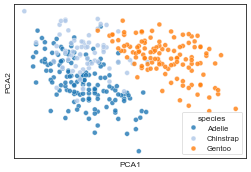

In [ ]:
# Reduce features and immediately plot the first two embedding dimensions.
plot_cluster(df[['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g', 'species']], method='pca', hue='species', legend=True)

<Axes: xlabel='bill_length_mm', ylabel='flipper_length_mm'>

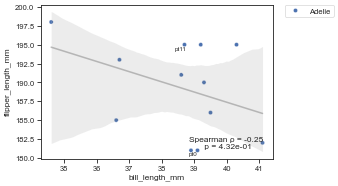

In [ ]:
# Plot a pairwise relationship with an optional correlation annotation.
df2 = df[['bill_length_mm', 'flipper_length_mm', 'species']].head(12).copy()
df2.index = [f'pt{i}' for i in range(len(df2))]
plot_rel(df2, x='bill_length_mm', y='flipper_length_mm', hue='species', index_list=['pt0', 'pt11'])

### 03 bar

In [ ]:
from kplot.bar import plot_hist, plot_count, plot_bar, plot_group_bar, plot_stacked, plot_violin, plot_box, plot_pie, plot_cnt, calculate_pct, plot_composition

In [ ]:
import seaborn as sns

# Set up the objects used by the examples below.
df = sns.load_dataset('tips').dropna()
df.shape

(244, 7)

<Axes: xlabel='total_bill', ylabel='Count'>

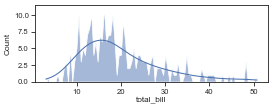

In [ ]:
# Plot a histogram with a KDE overlay and polygon bins.
plot_hist(df, 'total_bill')

<Axes: >

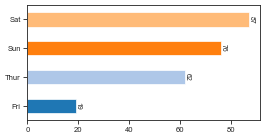

In [ ]:
# Plot horizontal counts from a value-count series.
plot_count(df['day'].value_counts())

<Axes: ylabel='total_bill'>

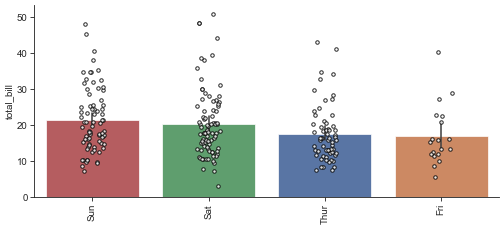

In [ ]:
# Plot a bar chart from an unstacked dataframe.
plot_bar(df, value='total_bill', group='day')

<Axes: ylabel='Value'>

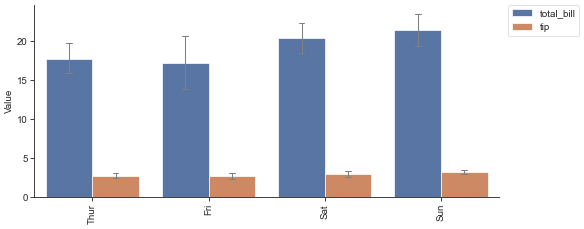

In [ ]:
# Plot grouped bars after melting multiple value columns.
plot_group_bar(df, value_cols=['total_bill', 'tip'], group='day')

<Axes: >

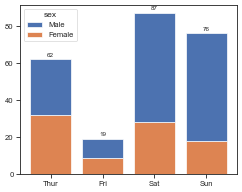

In [ ]:
# Plot stacked counts for a categorical column.
plot_stacked(df, group='day', hue='sex')

<Axes: ylabel='value'>

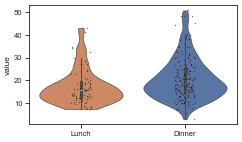

In [ ]:
# Plot violin plots with optional strip dots.
df2 = df[['time', 'total_bill']].rename(columns={'time': 'variable', 'total_bill': 'value'})
plot_violin(df2)

<Axes: ylabel='total_bill'>

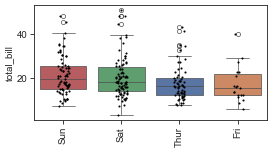

In [ ]:
# Plot a box plot ordered by the group median.
plot_box(df, value='total_bill', group='day')

<Axes: title={'center': 'n=244'}>

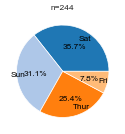

In [ ]:
# Plot a pie chart from a value-count series.
plot_pie(df['day'].value_counts())

<Axes: ylabel='Count'>

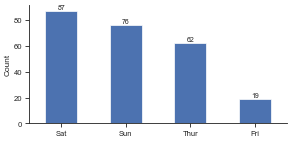

In [ ]:
# Plot vertical counts with labels above the bars.
plot_cnt(df['day'].value_counts())

In [ ]:
# Calculate within-bin percentages for a stacked composition chart.
df2 = sns.load_dataset('titanic').dropna(subset=['class', 'sex']).reset_index(drop=True)
calculate_pct(df2, 'class', 'sex')

sex,female,male
class,,
First,43.518519,56.481481
Second,41.304348,58.695652
Third,29.327902,70.672098


<Axes: ylabel='Percentage'>

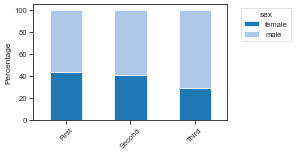

In [ ]:
# Plot stacked percentages for a bin-by-category composition.
plot_composition(df2, 'class', 'sex')

### 04 heatmap

In [ ]:
from kplot.heatmap import get_similarity, plot_corr, plot_confusion_matrix

In [ ]:
import seaborn as sns

# Set up the objects used by the examples below.
df = sns.load_dataset('titanic').dropna(subset=['age', 'fare', 'class', 'sex', 'survived']).reset_index(drop=True)
df2 = df[['age', 'fare', 'sibsp', 'parch']].head(8).copy()
df2.index = [f'row_{i}' for i in range(len(df2))]
print(df.shape)
print(df2.shape)

(714, 15)
(8, 4)


In [ ]:
# Calculate both distance and similarity matrices for a dataframe.
get_similarity(df2)[0]

,row_0,row_1,row_2,row_3,row_4,row_5,row_6,row_7
row_0,0.000000,66.001996,4.177993,47.657345,13.062925,54.911521,24.415786,6.714166
row_1,66.001996,0.000000,64.492435,18.429118,63.312323,25.182682,61.821302,61.188418
row_2,4.177993,64.492435,0.000000,46.073643,9.000868,52.100901,27.548548,3.910651
row_3,47.657345,18.429118,46.073643,0.000000,45.061097,19.066500,46.039121,42.780883
row_4,13.062925,63.312323,9.000868,45.061097,0.000000,47.754949,35.618122,8.803791
row_5,54.911521,25.182682,52.100901,19.066500,47.754949,0.000000,60.513388,48.906725
row_6,24.415786,61.821302,27.548548,46.039121,35.618122,60.513388,0.000000,27.089433
row_7,6.714166,61.188418,3.910651,42.780883,8.803791,48.906725,27.089433,0.000000


<Axes: >

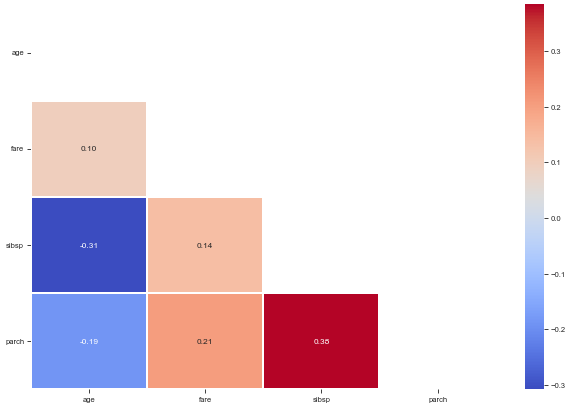

In [ ]:
# Plot a square matrix with an optional triangular mask.
plot_corr(df[['age', 'fare', 'sibsp', 'parch']].corr(numeric_only=True))

Normalized confusion matrix


<Axes: title={'center': 'Confusion matrix'}, xlabel='Predicted label', ylabel='True label'>

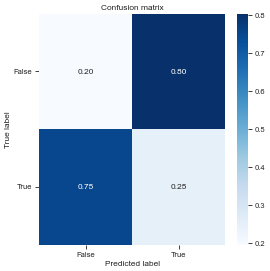

In [ ]:
# Plot a confusion matrix from target and prediction arrays.
plot_confusion_matrix(df['survived'], df['adult_male'], class_names=['False', 'True'], normalize=True)

### 05 hierarchical

In [ ]:
from kplot.hierarchical import get_1d_distance, get_1d_distance_parallel, get_Z, plot_dendrogram, get_hcluster

In [ ]:
import pandas as pd,numpy as np,seaborn as sns
from scipy.spatial.distance import euclidean

# Set up the objects used by the examples below.
df0=sns.load_dataset("iris")
df = df0.drop(columns="species")

def my_distance(u, v):
    return np.sum(np.abs(u - v))

A = np.array([[0, 0], [1, 1], [2, 2]])

df0.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [ ]:
# Compute 1D distance (like pdist from scipy) but for df with column names
# return 1d distance
get_1d_distance(pd.DataFrame(A),func_flat=my_distance)

100%|██████████| 3/3 [00:00<00:00, 3381.59it/s]


array([2, 4, 2])

In [ ]:
# Parallel compute 1D distance for each row in a dataframe given a distance function
# get_1d_distance_parallel(df, func_flat=my_distance)

In [ ]:
# Get linkage matrix Z from pssms dataframe
Z = get_Z(df,func_flat=euclidean,parallel=False)

100%|██████████| 150/150 [00:00<00:00, 532.10it/s]


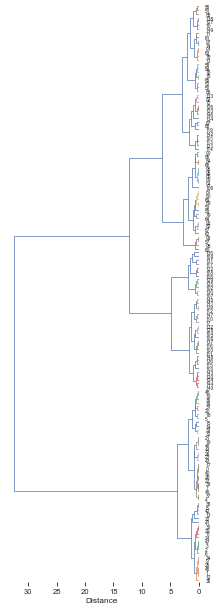

In [ ]:
# Run the example.
plot_dendrogram(Z,dense=10,labels=df.index,thr=0.5)

0      1
1      1
2      1
3      1
4      1
      ..
145    2
146    4
147    2
148    2
149    4
Length: 150, dtype: int32

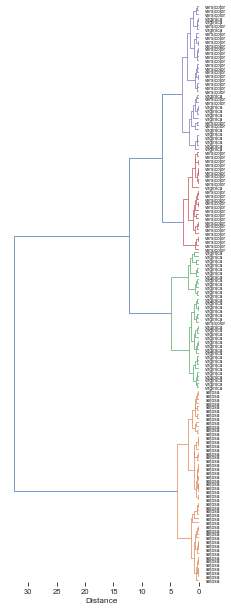

In [ ]:
# Get flat cluster assignments from hierarchical clustering linkage matrix `Z`.
get_hcluster(df,labels=df0['species'].tolist(),thr=5,dense=10)

### 06 ranking

In [ ]:
from kplot.ranking import plot_rank, get_AUCDF

In [ ]:
import seaborn as sns

# Set up the objects used by the examples below.
df = sns.load_dataset('tips')
df.shape

(244, 7)

In [ ]:
# Plot a ranked scatter and annotate the highest and lowest entries.
sort_df=df.sort_values('total_bill').copy()
sort_df['id'] = sort_df.index.astype(str)

<Axes: xlabel='id', ylabel='total_bill'>

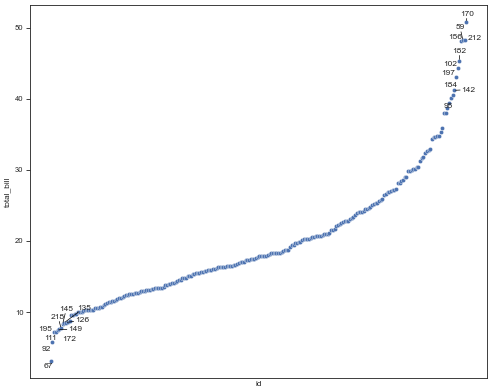

In [ ]:
plot_rank(sort_df, x='id', y='total_bill', n_hi=10, n_lo=10)

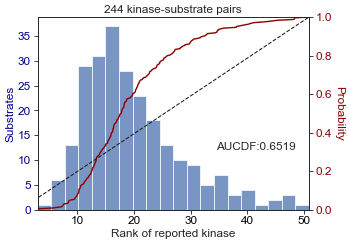

0.6519265042202643

In [ ]:
# Compute the normalized area under an empirical CDF over rank values.
get_AUCDF(df, 'total_bill', plot=True)